In [501]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [502]:
df = pd.read_csv('datasets/placement2.csv')

In [503]:
df.shape

(1000, 3)

In [504]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [505]:
df.sample(5)

,cgpa,placement_exam_marks,placed
648,7.15,24.0,0
321,6.82,47.0,0
904,7.36,32.0,0
70,6.98,17.0,1
830,6.46,28.0,0


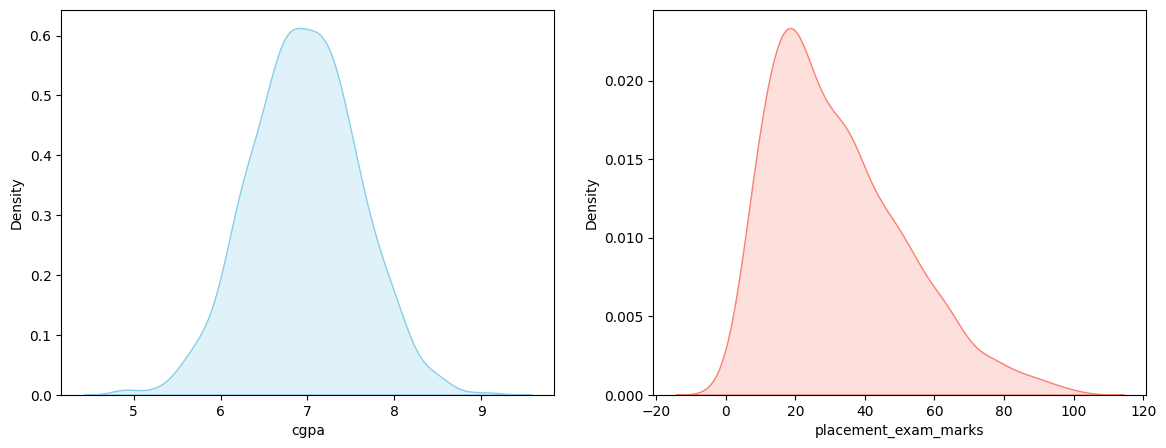

In [506]:
fig, (ax1,ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14,5))

sns.kdeplot(df['cgpa'], fill=True, color='skyblue', ax=ax1)

sns.kdeplot(df['placement_exam_marks'], fill=True, color='salmon', ax=ax2)

plt.show()

In [507]:
print("cgpa Mean: ", df['cgpa'].mean())
print("cgpa std: ", df['cgpa'].std())
print("cgpa max: ", df['cgpa'].max())
print("cgpa min: ", df['cgpa'].min())

cgpa Mean:  6.96124
cgpa std:  0.6158978751323896
cgpa max:  9.12
cgpa min:  4.89


In [508]:
print("Height value allowed: ",df['cgpa'].mean() + (3 * df['cgpa'].std()))
print("Lowest value allowed: ",df['cgpa'].mean() - (3 * df['cgpa'].std()))

Height value allowed:  8.808933625397168
Lowest value allowed:  5.113546374602832


In [509]:
df[(df['cgpa'] > 8.81) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


## Trimming

In [510]:
new_df = df[(df['cgpa'] < 8.81) & (df['cgpa'] > 5.11)]

In [511]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [512]:
new_df.shape

(995, 3)

In [513]:
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [514]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [515]:
from scipy.stats import zscore

In [516]:
df['cgpa_zscore'] = zscore(df['cgpa'])

In [517]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371611
1,7.46,38.0,1,0.810215
2,7.54,40.0,1,0.940171
3,6.42,8.0,1,-0.879222
4,7.23,17.0,0,0.436589


In [518]:
df[df['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.100701
996,9.12,65.0,1,3.506815


In [519]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.315909
997,4.89,34.0,0,-3.364643
999,4.90,10.0,1,-3.348398


In [520]:
df[(df['cgpa_zscore'] > 3) | (df['cgpa_zscore'] < -3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.315909
995,8.87,44.0,1,3.100701
996,9.12,65.0,1,3.506815
997,4.89,34.0,0,-3.364643
999,4.90,10.0,1,-3.348398


In [521]:
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [522]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371611
1,7.46,38.0,1,0.810215
2,7.54,40.0,1,0.940171
3,6.42,8.0,1,-0.879222
4,7.23,17.0,0,0.436589
...,...,...,...,...
991,7.04,57.0,0,0.127942
992,6.26,12.0,0,-1.139135
993,6.73,21.0,1,-0.375640
994,6.48,63.0,0,-0.781754


In [523]:
new_df.shape

(995, 4)

## Capping

In [524]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [525]:
upper_limit

np.float64(8.808933625397168)

In [526]:
df['cgpa'] = np.where(
    df['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        df['cgpa'] < lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [527]:
df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371611
1,7.460000,38.0,1,0.810215
2,7.540000,40.0,1,0.940171
3,6.420000,8.0,1,-0.879222
4,7.230000,17.0,0,0.436589
...,...,...,...,...
995,8.808934,44.0,1,3.100701
996,8.808934,65.0,1,3.506815
997,5.113546,34.0,0,-3.364643
998,8.620000,46.0,1,2.694586


In [528]:
df.shape

(1000, 4)

In [529]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

In [530]:
df    

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371611
1,7.460000,38.0,1,0.810215
2,7.540000,40.0,1,0.940171
3,6.420000,8.0,1,-0.879222
4,7.230000,17.0,0,0.436589
...,...,...,...,...
995,8.808934,44.0,1,3.100701
996,8.808934,65.0,1,3.506815
997,5.113546,34.0,0,-3.364643
998,8.620000,46.0,1,2.694586


In [531]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [532]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

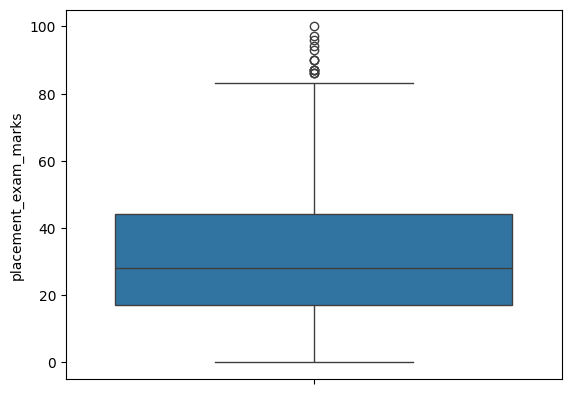

In [533]:
sns.boxplot(df['placement_exam_marks']);

In [534]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [535]:
percentile75

np.float64(44.0)

In [536]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [537]:
upper_limit1 = percentile75 + 1.5 * iqr
lower_limit1 = percentile25 - 1.5 * iqr

In [538]:
print("Upper limit1",upper_limit1)
print("Lower limit1",lower_limit1)

Upper limit1 84.5
Lower limit1 -23.5


In [539]:
df[df['placement_exam_marks'] > upper_limit1]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.281308
40,6.60,86.0,1,-0.586819
61,7.51,86.0,0,0.891438
134,6.33,93.0,0,-1.025423
162,7.80,90.0,0,1.362531
283,7.09,87.0,0,0.209165
290,8.38,87.0,0,2.304716
311,6.97,87.0,1,0.014230
324,6.64,90.0,0,-0.521841
630,6.56,96.0,1,-0.651798


In [540]:
df[df['placement_exam_marks'] < lower_limit1]

,cgpa,placement_exam_marks,placed,cgpa_zscore


In [541]:
new_df1 = df[df['placement_exam_marks'] < upper_limit1]

In [542]:
new_df1

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371611
1,7.460000,38.0,1,0.810215
2,7.540000,40.0,1,0.940171
3,6.420000,8.0,1,-0.879222
4,7.230000,17.0,0,0.436589
...,...,...,...,...
995,8.808934,44.0,1,3.100701
996,8.808934,65.0,1,3.506815
997,5.113546,34.0,0,-3.364643
998,8.620000,46.0,1,2.694586


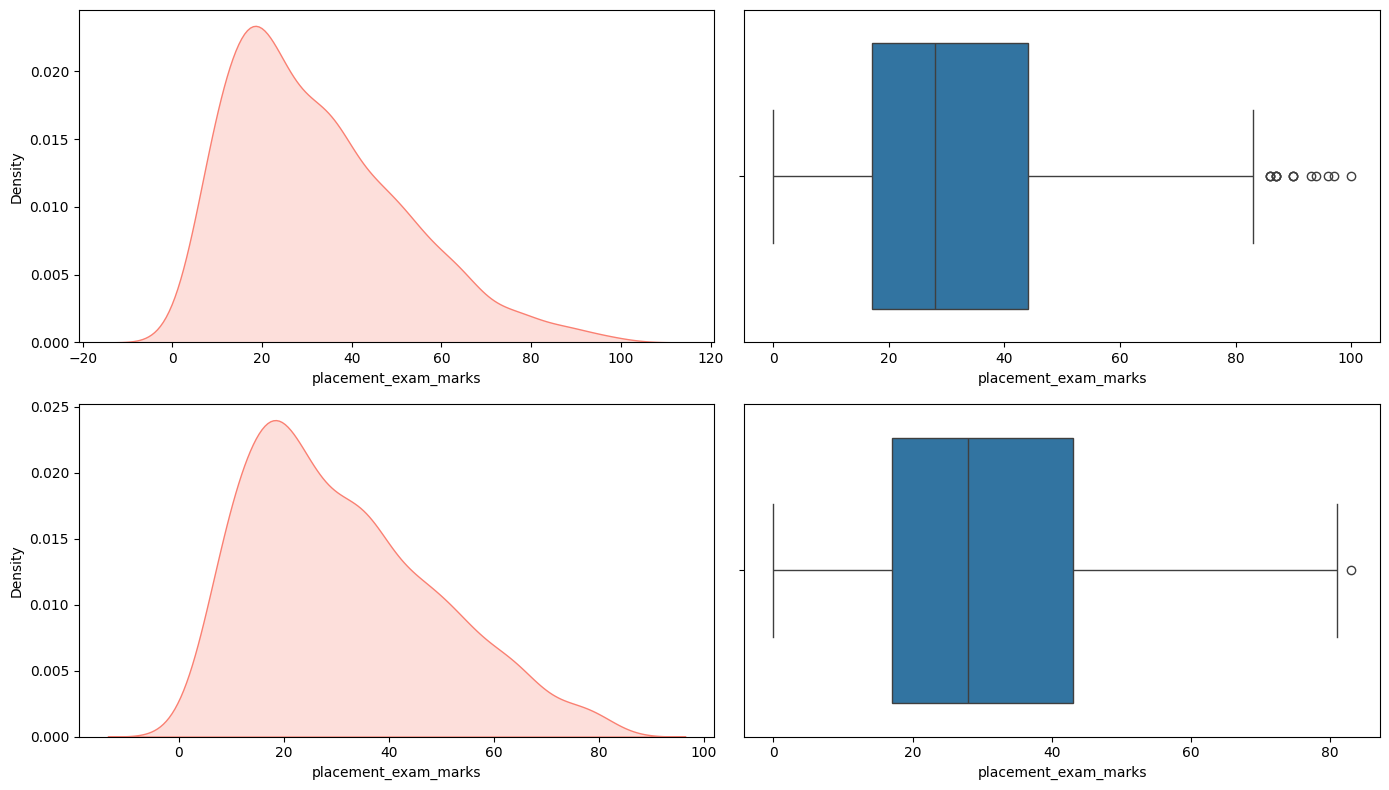

In [543]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

sns.kdeplot(df['placement_exam_marks'], fill=True, color='salmon', ax=axes[0,0])
sns.boxplot(x=df['placement_exam_marks'], ax=axes[0,1])

sns.kdeplot(new_df1['placement_exam_marks'], fill=True, color='salmon', ax=axes[1,0])
sns.boxplot(x=new_df1['placement_exam_marks'], ax=axes[1,1])

plt.tight_layout()
plt.show()

In [544]:
new_df_cap = df.copy()

In [545]:
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit1,
    upper_limit1,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit1,
        lower_limit1,
        new_df_cap['placement_exam_marks']
    )
)

In [546]:
new_df_cap.shape

(1000, 4)

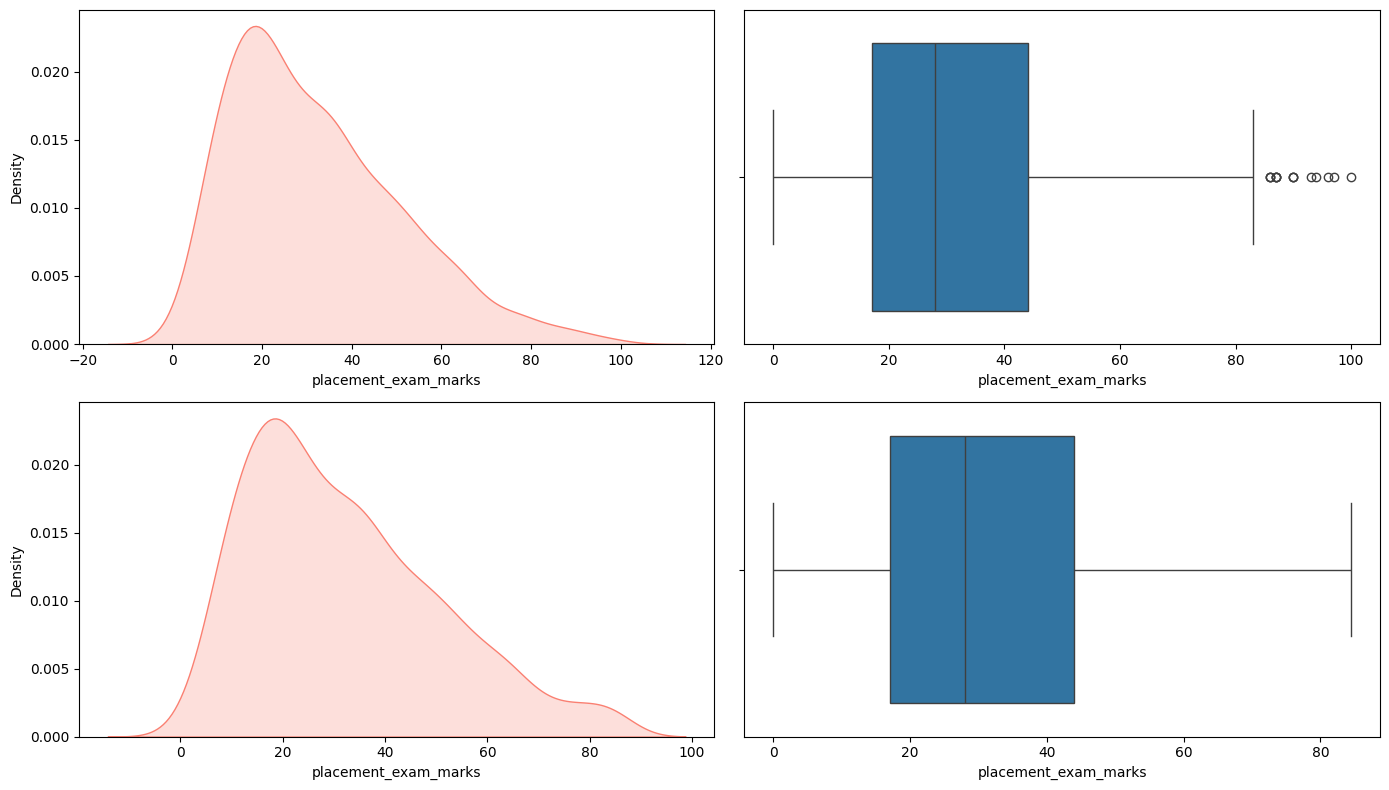

In [547]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))

sns.kdeplot(df['placement_exam_marks'], fill=True, color='salmon', ax=axes[0,0])
sns.boxplot(x=df['placement_exam_marks'], ax=axes[0,1])

sns.kdeplot(new_df_cap['placement_exam_marks'], fill=True, color='salmon', ax=axes[1,0])
sns.boxplot(x=new_df_cap['placement_exam_marks'], ax=axes[1,1])

plt.tight_layout()
plt.show()

In [548]:
df1 = pd.read_csv('datasets/weight-height.csv')

In [549]:
df1.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [550]:
df1.shape

(10000, 3)

In [551]:
df1['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

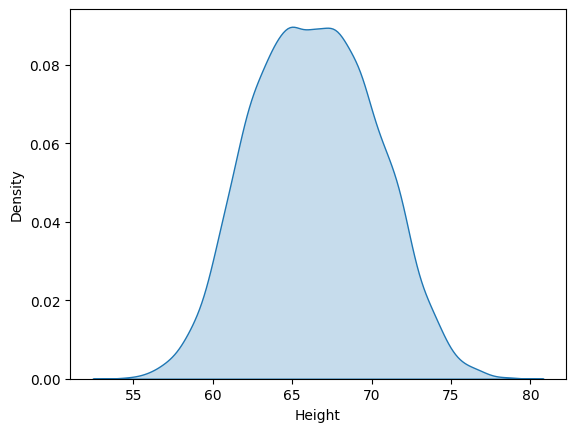

In [552]:
sns.kdeplot(x=df1['Height'], fill=True)

<Axes: xlabel='Height'>

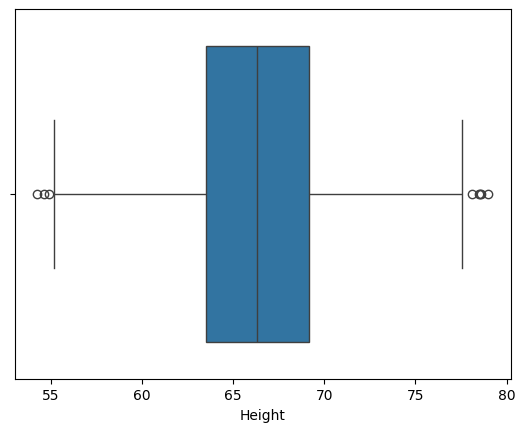

In [553]:
sns.boxplot(x=df1['Height'])

In [554]:
upper_limit2 = df1['Height'].quantile(0.99)
lower_limit2 = df1['Height'].quantile(0.01)

In [555]:
lower_limit2

np.float64(58.13441158671655)

In [556]:
df1[(df1['Height'] >= upper_limit2) | (df1['Height'] <=lower_limit2)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [557]:
new_df2 = df1[(df1['Height'] < upper_limit2) & (df1['Height'] > lower_limit2)]
new_df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [558]:
new_df2['Height'].describe(), df1['Height'].describe()

(count    9800.000000
 mean       66.364366
 std         3.645075
 min        58.134496
 25%        63.577162
 50%        66.318070
 75%        69.119896
 max        74.785714
 Name: Height, dtype: float64,
 count    10000.000000
 mean        66.367560
 std          3.847528
 min         54.263133
 25%         63.505620
 50%         66.318070
 75%         69.174262
 max         78.998742
 Name: Height, dtype: float64)

<Axes: xlabel='Height', ylabel='Density'>

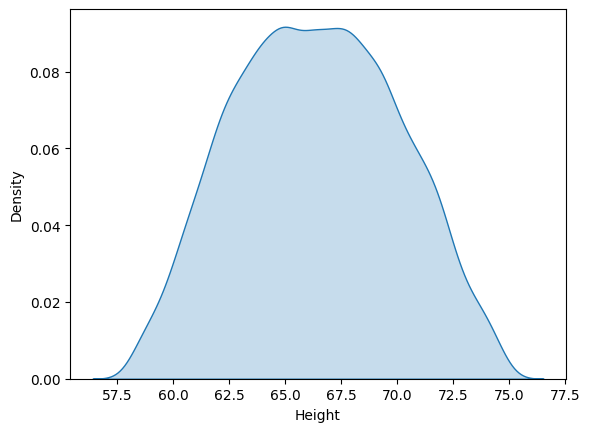

In [559]:
sns.kdeplot(x=new_df2['Height'], fill=True)

<Axes: xlabel='Height', ylabel='Density'>

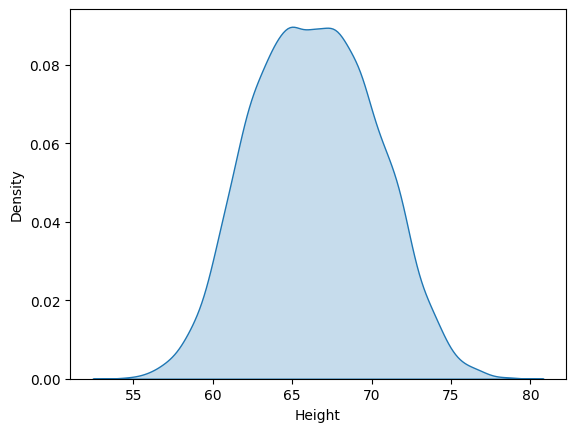

In [560]:
sns.kdeplot(x=df1['Height'], fill=True)

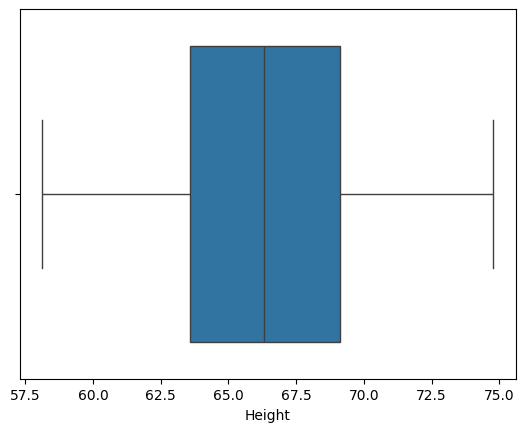

In [561]:
sns.boxplot(x = new_df2['Height']);

In [564]:
df1['Height'] = np.where(
    df1['Height'] > upper_limit2,
    upper_limit2,
    np.where(
    df1['Height'] > lower_limit2,
    lower_limit2,   
    df1['Height'] 
    )
)

In [565]:
df1.shape

(10000, 3)